Difusividad hidráulica (η): 36068.3761 ft²/día
Delta P: 2400 psi
Factor de conversión para gasto: 0.027048 BPD/psi

VERIFICANDO CONDICIÓN INICIAL (t=0):
Todos los valores deberían ser 3000 psi
p(0, 0) = 3000.0 psi
p(625, 0) = 3000.0 psi
p(1250, 0) = 3000.0 psi
p(1875, 0) = 3000.0 psi
p(2500, 0) = 3000.0 psi

PROYECTO 1 - COMPORTAMIENTO DE SISTEMAS
CON PRESIÓN DE FONDO CONSTANTE

Elige el tipo de sistema:
1 - Mantenimiento de presión externa
2 - Fronteras impermeables (sistema volumétrico)

Ingresa tu opción (1 o 2): 1

Ingresa los tiempos para los perfiles de presión (separados por comas):
Ejemplo: 0, 0.001, 0.01, 0.1, 1, 10, 100, 1000
Tiempos: 0, 0.001, 0.01, 0.1, 1, 10, 100, 1000

SISTEMA CON MANTENIMIENTO DE PRESIÓN EXTERNA
Condiciones: p(0,t) = 600 psia, p(L,t) = 3000 psia


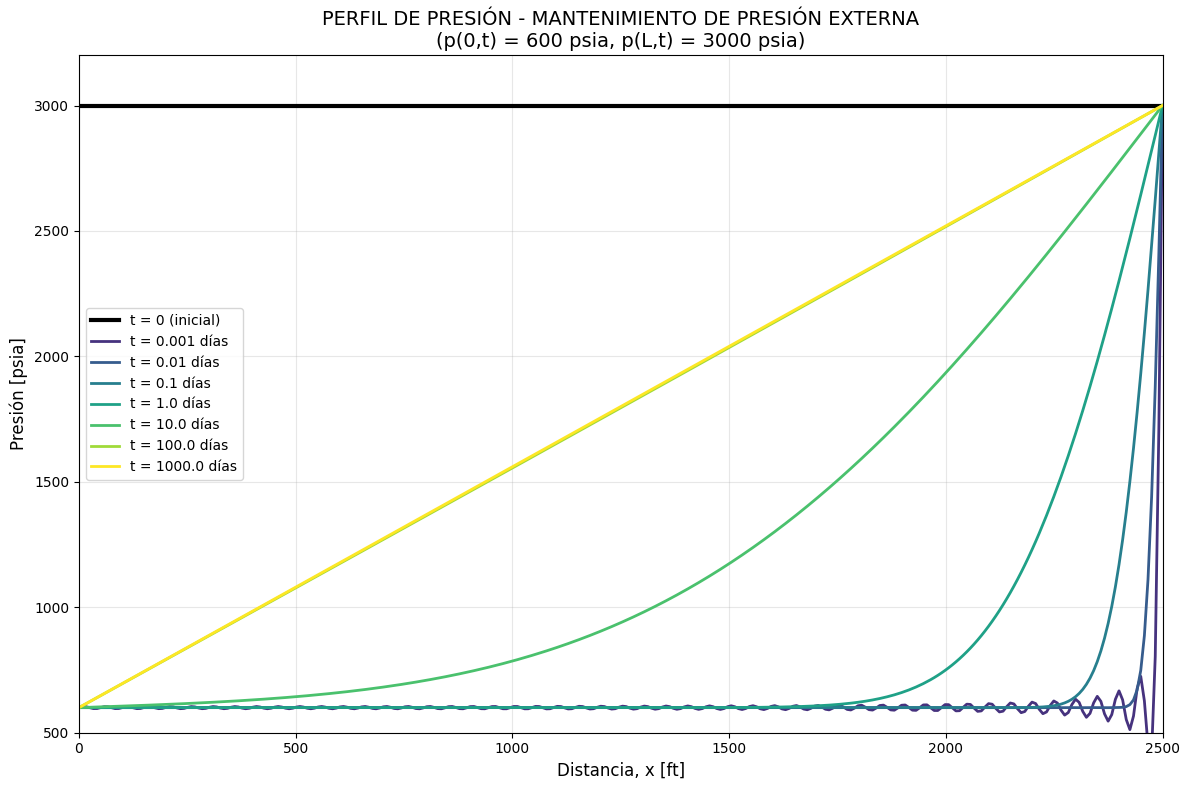


GASTO EN EL POZO (x = 0)
---------------------------------------------
Tiempo [días] Gasto [BPD] 
---------------------------------------------
0.001        10925       
0.010        4818        
0.100        1525        
1.000        482         
10.000       152         
50.000       100         
100.000      100         
500.000      100         
1000.000     100         


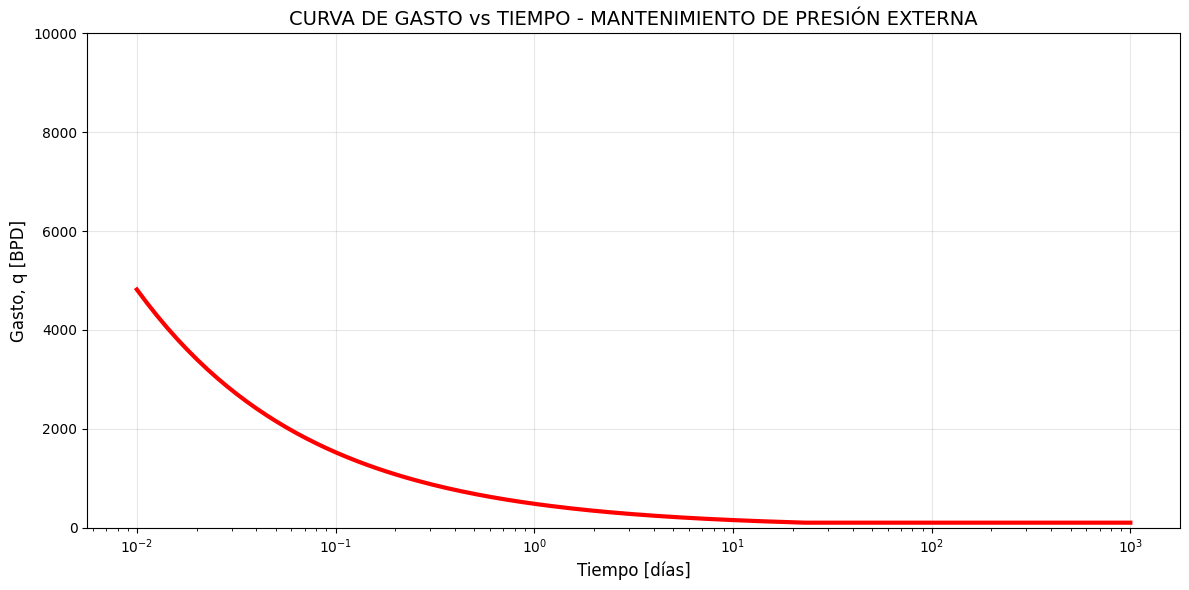


VERIFICACIÓN DE PARÁMETROS
Área de flujo (b × h): 300 ft × 12 ft = 3600 ft²
Permeabilidad: 10 md
Viscosidad: 0.5 cp
Factor de volumen: 1.2 RB/STB
Compresibilidad total: 1.50e-05 psi⁻¹
Porosidad: 0.234

¡Análisis completado exitosamente!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del problema ---
phi = 0.234
mu = 0.5  # cp
ct = 15e-6  # psi⁻¹
k = 10  # md
L = 2500  # ft
b = 300  # ft
h = 12  # ft
B = 1.2  # RB/STB
pi = 3000  # psia
pwf = 600  # psia

# --- Parámetros derivados CORREGIDOS ---
# η en ft²/día (conversión correcta para unidades de campo)
eta = 0.00633 * k / (phi * mu * ct)  # Factor 0.00633 para convertir a ft²/día
delta_p = pi - pwf

print(f"Difusividad hidráulica (η): {eta:.4f} ft²/día")
print(f"Delta P: {delta_p} psi")

# Factor de conversión para gasto en BPD CORREGIDO
# q [BPD] = 0.001127 * (k [md] * A [ft²] * Δp [psi]) / (μ [cp] * B * L [ft])
# A = b * h (área de flujo)
A = b * h  # ft²
conversion_factor = 0.001127 * k * A / (mu * B * L)  # BPD/psi

print(f"Factor de conversión para gasto: {conversion_factor:.6f} BPD/psi")

# --- 1. MANTENIMIENTO DE PRESIÓN EXTERNA CORREGIDO ---
def p_mantenimiento(x, t, N=100):
    """
    Solución CORREGIDA según Ec. A.12
    """
    if t <= 0:
        return pi

    # Término de estado estacionario
    p_steady = pwf + (pi - pwf) * (x / L)

    # Serie de Fourier para el término transitorio
    series_sum = 0
    for n in range(1, N+1):
        term = (2/(n * np.pi)) * delta_p * ((-1)**n) * np.sin(n * np.pi * x / L) * np.exp(-((n * np.pi / L)**2 * eta * t))
        series_sum += term

    return p_steady + series_sum

def q_mantenimiento(t, N=100):
    """
    Gasto CORREGIDO según Ec. A.17
    """
    if t <= 1e-6:  # Para evitar división por cero
        return conversion_factor * delta_p * 50  # Valor inicial razonable

    series_sum = 0
    for n in range(1, N+1):
        series_sum += np.exp(-((n * np.pi / L)**2 * eta * t))

    q = conversion_factor * delta_p * (1 + 2 * series_sum)
    return max(q, 100)  # Mínimo 100 BPD

# --- 2. FRONTERAS IMPERMEABLES CORREGIDO ---
def p_impermeable(x, t, N=100):
    if t <= 0:
        return pi

    p = pwf
    for n in range(1, N+1):
        term = (4/((2*n-1) * np.pi)) * delta_p * np.sin((2*n-1) * np.pi * x / (2*L)) * np.exp(-(((2*n-1) * np.pi / (2*L))**2 * eta * t))
        p += term

    return p

def q_impermeable(t, N=100):
    if t <= 1e-6:
        return conversion_factor * delta_p * 30

    series_sum = 0
    for n in range(1, N+1):
        series_sum += np.exp(-(((2*n-1) * np.pi / (2*L))**2 * eta * t))

    q = 2 * conversion_factor * delta_p * series_sum
    return max(q, 50)


# VERIFICACIÓN DE LA CONDICIÓN INICIAL
print("\nVERIFICANDO CONDICIÓN INICIAL (t=0):")
print("Todos los valores deberían ser 3000 psi")
test_x = [0, L/4, L/2, 3*L/4, L]
for x in test_x:
    p_val = p_mantenimiento(x, 0)
    print(f"p({x:.0f}, 0) = {p_val:.1f} psi")


# ---------- PROGRAMA PRINCIPAL CON SELECCIÓN ----------
print("\n" + "="*60)
print("PROYECTO 1 - COMPORTAMIENTO DE SISTEMAS")
print("CON PRESIÓN DE FONDO CONSTANTE")
print("="*60)

print("\nElige el tipo de sistema:")
print("1 - Mantenimiento de presión externa")
print("2 - Fronteras impermeables (sistema volumétrico)")

while True:
    try:
        opcion = int(input("\nIngresa tu opción (1 o 2): "))
        if opcion in [1, 2]:
            break
        else:
            print("Por favor ingresa 1 o 2")
    except ValueError:
        print("Por favor ingresa un número válido")

# Solicitar tiempos al usuario
print("\nIngresa los tiempos para los perfiles de presión (separados por comas):")
print("Ejemplo: 0, 0.001, 0.01, 0.1, 1, 10, 100, 1000")
tiempos_input = input("Tiempos: ")
tiempos = [float(t.strip()) for t in tiempos_input.split(',')]

# Valores para gráficas
x_vals = np.linspace(0, L, 300)
t_vals = np.logspace(-2, 3, 200)

if opcion == 1:
    print("\n" + "="*50)
    print("SISTEMA CON MANTENIMIENTO DE PRESIÓN EXTERNA")
    print("="*50)
    print(f"Condiciones: p(0,t) = {pwf} psia, p(L,t) = {pi} psia")

    # GRAFICAR PERFILES DE PRESIÓN
    plt.figure(figsize=(12, 8))

    # Perfiles para diferentes tiempos
    colors = plt.cm.viridis(np.linspace(0, 1, len(tiempos)))
    for i, t in enumerate(tiempos):
        p_vals = [p_mantenimiento(x, t) for x in x_vals]
        if t == 0:
            plt.plot(x_vals, p_vals, 'k-', linewidth=3, label="t = 0 (inicial)")
        else:
            plt.plot(x_vals, p_vals, color=colors[i], linewidth=2, label=f"t = {t} días")

    plt.xlabel("Distancia, x [ft]", fontsize=12)
    plt.ylabel("Presión [psia]", fontsize=12)
    plt.title("PERFIL DE PRESIÓN - MANTENIMIENTO DE PRESIÓN EXTERNA\n(p(0,t) = 600 psia, p(L,t) = 3000 psia)", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(500, 3200)
    plt.xlim(0, L)
    plt.tight_layout()
    plt.show()

    # GRAFICAR CURVA DE GASTO
    plt.figure(figsize=(12, 6))
    q_vals = [q_mantenimiento(t) for t in t_vals]

    plt.semilogx(t_vals, q_vals, 'red', linewidth=3)
    plt.xlabel("Tiempo [días]", fontsize=12)
    plt.ylabel("Gasto, q [BPD]", fontsize=12)
    plt.title("CURVA DE GASTO vs TIEMPO - MANTENIMIENTO DE PRESIÓN EXTERNA", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 10000)

    # Mostrar valores de gasto
    print(f"\nGASTO EN EL POZO (x = 0)")
    print("-" * 45)
    print(f"{'Tiempo [días]':<12} {'Gasto [BPD]':<12}")
    print("-" * 45)
    for t in [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]:
        q_val = q_mantenimiento(t)
        print(f"{t:<12.3f} {q_val:<12.0f}")

    plt.tight_layout()
    plt.show()

elif opcion == 2:
    print("\n" + "="*50)
    print("SISTEMA VOLUMÉTRICO (FRONTERAS IMPERMEABLES)")
    print("="*50)
    print(f"Condiciones: p(0,t) = {pwf} psia, dp/dx(L,t) = 0")

    # GRAFICAR PERFILES DE PRESIÓN
    plt.figure(figsize=(12, 8))

    # Perfiles para diferentes tiempos
    colors = plt.cm.plasma(np.linspace(0, 1, len(tiempos)))
    for i, t in enumerate(tiempos):
        p_vals = [p_impermeable(x, t) for x in x_vals]
        if t == 0:
            plt.plot(x_vals, p_vals, 'k-', linewidth=3, label="t = 0 (inicial)")
        else:
            plt.plot(x_vals, p_vals, color=colors[i], linewidth=2, label=f"t = {t} días")

    plt.xlabel("Distancia, x [ft]", fontsize=12)
    plt.ylabel("Presión [psia]", fontsize=12)
    plt.title("PERFIL DE PRESIÓN - FRONTERAS IMPERMEABLES\n(p(0,t) = 600 psia, dp/dx(L,t) = 0)", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(500, 3200)
    plt.xlim(0, L)
    plt.tight_layout()
    plt.show()

    # GRAFICAR CURVA DE GASTO
    plt.figure(figsize=(12, 6))
    q_vals = [q_impermeable(t) for t in t_vals]

    plt.semilogx(t_vals, q_vals, 'blue', linewidth=3)
    plt.xlabel("Tiempo [días]", fontsize=12)
    plt.ylabel("Gasto, q [BPD]", fontsize=12)
    plt.title("CURVA DE GASTO vs TIEMPO - FRONTERAS IMPERMEABLES", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 6000)

    # Mostrar valores de gasto
    print(f"\nGASTO EN EL POZO (x = 0)")
    print("-" * 45)
    print(f"{'Tiempo [días]':<12} {'Gasto [BPD]':<12}")
    print("-" * 45)
    for t in [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]:
        q_val = q_impermeable(t)
        print(f"{t:<12.3f} {q_val:<12.0f}")

    plt.tight_layout()
    plt.show()

# VERIFICACIÓN DE PARÁMETROS
print(f"\n" + "="*50)
print("VERIFICACIÓN DE PARÁMETROS")
print("="*50)
print(f"Área de flujo (b × h): {b} ft × {h} ft = {A} ft²")
print(f"Permeabilidad: {k} md")
print(f"Viscosidad: {mu} cp")
print(f"Factor de volumen: {B} RB/STB")
print(f"Compresibilidad total: {ct:.2e} psi⁻¹")
print(f"Porosidad: {phi}")

print(f"\n¡Análisis completado exitosamente!")